In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
!pip install keras-tuner

In [14]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
import tensorflow as tf
import keras
import keras_tuner as kt
from sklearn.model_selection import train_test_split
import os

In [15]:
print(keras.__version__)

3.8.0


In [16]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [17]:
# Define CIFAR-10 class labels
cifar10_labels = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

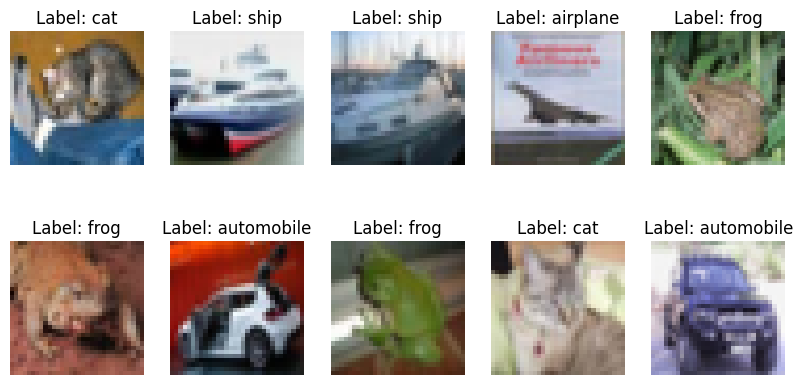

In [18]:
# Display a few sample images with labels
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i])
    ax.set_title(f"Label: {cifar10_labels[y_test[i][0]]}")
    ax.axis("off")
plt.show()

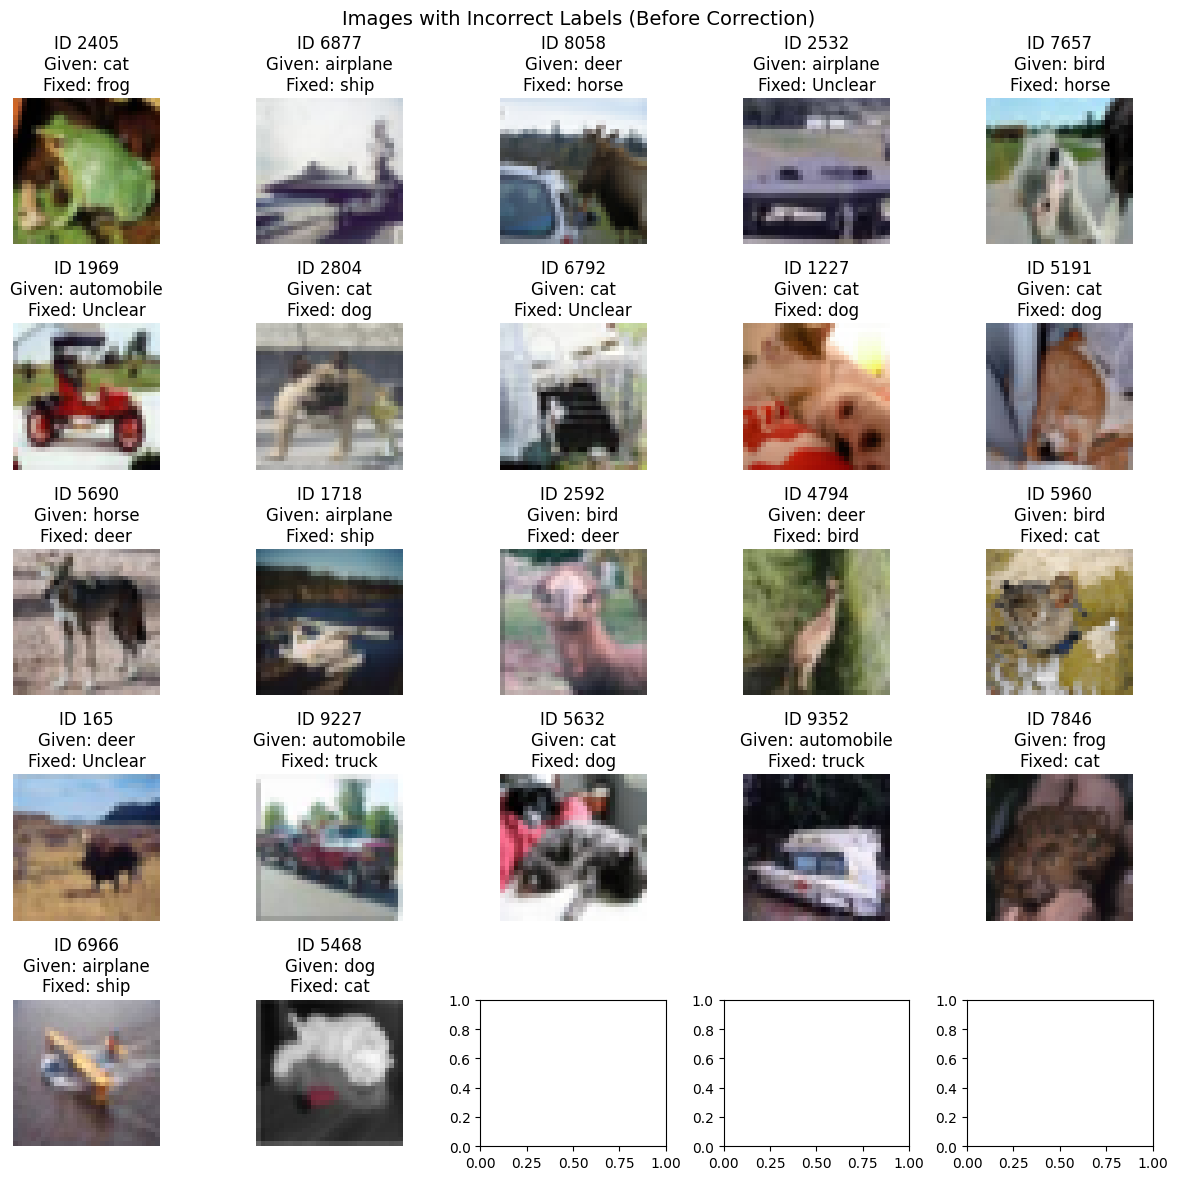

In [19]:
# Define incorrectly labeled CIFAR-10 test image IDs and their corrected labels
incorrect_labels = {
    2405: "frog", 6877: "ship", 8058: "horse", 2532: None, 7657: "horse",
    1969: None, 2804: "dog", 6792: None, 1227: "dog", 5191: "dog",
    5690: "deer", 1718: "ship", 2592: "deer", 4794: "bird", 5960: "cat",
    165: None, 9227: "truck", 5632: "dog", 9352: "truck", 7846: "cat",
    6966: "ship", 5468: "cat"
}

# Display images with incorrect labels and their corrected labels
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
fig.suptitle("Images with Incorrect Labels (Before Correction)", fontsize=14)

for i, (idx, correct_label) in enumerate(incorrect_labels.items()):
    if i < 25:  # Show up to 25 images
        ax = axes[i // 5, i % 5]
        ax.imshow(x_test[idx])
        current_label = cifar10_labels[y_test[idx][0]]
        ax.set_title(f"ID {idx}\nGiven: {current_label}\nFixed: {correct_label if correct_label else 'Unclear'}")
        ax.axis("off")

plt.tight_layout()
plt.show()


In [20]:
# Convert correct labels to numeric values based on cifar10_labels
corrected_indices = {idx: cifar10_labels.index(label) for idx, label in incorrect_labels.items() if label}

# Apply corrections to y_test
y_test_fixed = y_test.copy()
for idx, correct_label_idx in corrected_indices.items():
    y_test_fixed[idx] = correct_label_idx

In [21]:
# Save the corrected labels for future use
np.save("/content/drive/MyDrive/datasets/y_test_fixed.npy", y_test_fixed)

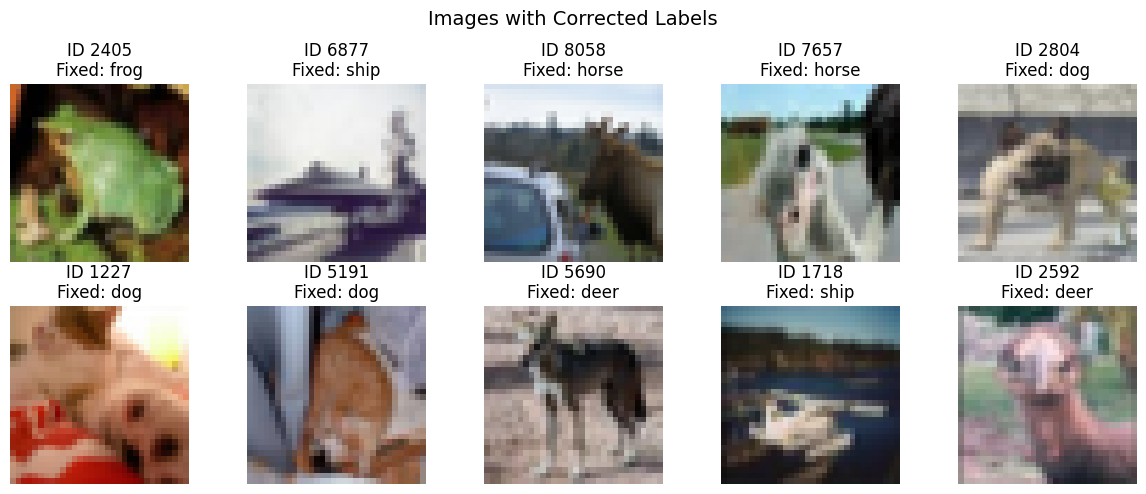

In [22]:
# Verify corrections by displaying modified labels for a few images
corrected_sample_ids = list(corrected_indices.keys())[:10]  # Show first 10 corrected images

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Images with Corrected Labels", fontsize=14)

for i, ax in enumerate(axes.flat):
    if i < len(corrected_sample_ids):
        idx = corrected_sample_ids[i]
        ax.imshow(x_test[idx])
        current_label = cifar10_labels[y_test_fixed[idx][0]]
        ax.set_title(f"ID {idx}\nFixed: {current_label}")
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [26]:
# Define the corrected model structure based on the uploaded model summary
def build_exact_model():
    model = keras.Sequential([
        # First Conv Block
        layers.Conv2D(32, (3,3), activation="relu", padding="valid", input_shape=(32,32,3)),  # (30, 30, 32)
        layers.AveragePooling2D((2,2)),  # (15, 15, 32)
        layers.BatchNormalization(),

        # Second Conv Block
        layers.Conv2D(64, (3,3), activation="relu", padding="valid"),  # (13, 13, 64)
        layers.AveragePooling2D((2,2)),  # (6, 6, 64)
        layers.BatchNormalization(),

        # Fully Connected Layers
        layers.Flatten(),  # (2304,)
        layers.Dense(256, activation="relu"),  # (256,)
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax")  # CIFAR-10 has 10 classes
    ])

    # Compile the model
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    return model

# Create and display the corrected model summary
exact_model = build_exact_model()
exact_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_4                  │ (None, 15, 15, 32)          │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 15, 15, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_5                  │ (None, 6, 6, 64)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 6, 6, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 612,426 (2.34 MB)

 Trainable params: 612,234 (2.34 MB)

 Non-trainable params: 192 (768.00 B)

## 고정 모델 확인

![](https://d3s0tskafalll9.cloudfront.net/media/images/Screenshot_from_2024-01-25_12-03-51.max-800x600.png)

In [27]:
# Import necessary libraries for KerasTuner
import keras_tuner as kt

# Define the tunable model
def build_tunable_model(hp):
    model = keras.Sequential([
        # First Conv Block (Fixed Structure)
        layers.Conv2D(32, (3,3), activation="relu", padding="valid", input_shape=(32,32,3)),  # (30, 30, 32)
        layers.AveragePooling2D((2,2)),  # (15, 15, 32)
        layers.BatchNormalization(),

        # Second Conv Block (Fixed Structure)
        layers.Conv2D(64, (3,3), activation="relu", padding="valid"),  # (13, 13, 64)
        layers.AveragePooling2D((2,2)),  # (6, 6, 64)
        layers.BatchNormalization(),

        # Fully Connected Layers
        layers.Flatten(),  # (2304,)
        layers.Dense(256, activation="relu"),  # (256,)
        layers.Dropout(hp.Float("dropout", min_value=0.3, max_value=0.5, step=0.1)),
        layers.Dense(10, activation="softmax")  # CIFAR-10 has 10 classes
    ])

    # Tunable optimizer and learning rate
    optimizer = hp.Choice("optimizer", ["adam", "rmsprop"])
    learning_rate = hp.Float("learning_rate", min_value=0.0001, max_value=0.01, sampling="LOG")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate) if optimizer == "adam" else keras.optimizers.RMSprop(learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [28]:
# Initialize KerasTuner with Hyperband Search
tuner = kt.Hyperband(
    build_tunable_model,
    objective="val_accuracy",
    max_epochs=10,  # Limit to 10 epochs for tuning speed
    factor=3,
    directory="keras_tuner_dir",
    project_name="cifar10_tuning"
)

In [29]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize pixel values to range [0,1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# Perform the hyperparameter search
tuner.search(x_train, y_train, epochs=10, validation_split=0.2, batch_size=64)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Print the best hyperparameter values
print(f"Best hyperparameters found:")
print(f"Dropout Rate: {best_hps.get('dropout')}")
print(f"Learning Rate: {best_hps.get('learning_rate')}")
print(f"Optimizer: {best_hps.get('optimizer')}")

Trial 30 Complete [00h 00m 46s]
val_accuracy: 0.6897000074386597

Best val_accuracy So Far: 0.7196999788284302
Total elapsed time: 00h 12m 19s
Best hyperparameters found:
Dropout Rate: 0.5
Learning Rate: 0.0008380093243360302
Optimizer: adam


In [31]:
# Build and train the final model with the best hyperparameters
final_model = tuner.hypermodel.build(best_hps)
history = final_model.fit(x_train, y_train, epochs=20, validation_split=0.2, batch_size=64)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.3698 - loss: 2.0801 - val_accuracy: 0.4773 - val_loss: 1.4764
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5753 - loss: 1.2077 - val_accuracy: 0.5589 - val_loss: 1.2655
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6457 - loss: 1.0128 - val_accuracy: 0.6635 - val_loss: 0.9851
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6891 - loss: 0.8762 - val_accuracy: 0.6967 - val_loss: 0.8799
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7236 - loss: 0.7830 - val_accuracy: 0.6768 - val_loss: 0.9503
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7541 - loss: 0.7017 - val_accuracy: 0.7089 - val_loss: 0.8435
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7755 - loss: 0.6278 - val_accuracy: 0.6971 - val_loss: 0.8822
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7936 - loss: 0.5780 - val_accuracy: 0.

In [34]:
# Save the trained model in SavedModel format
final_model.export("/content/drive/MyDrive/model/cifar10_tuned_model")

print("✅ Model training complete and saved in SavedModel format!")


Saved artifact at '/content/drive/MyDrive/model/cifar10_tuned_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_22')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  133776275329808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133776275329040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133776275330000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133776275330768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133776275326160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133776275330384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133776275326352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133776264552592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133776264556240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133776264549712: TensorSpec(shape=(), dtype=tf.res

# 모델 배포


![](assets/deploy_confirmed.png)

## 배포된 모델로 샘플 테스트

In [ ]:
import json
import requests

# Create a simple test image (all zeros)
test_image = [[[0.0] * 3] * 32] * 32
test_data = [test_image]  # Batch size 1

# Prepare the data for the request
data = json.dumps({
    "signature_name": "serving_default",
    "instances": test_data
})

# Send request to TensorFlow Serving
headers = {"content-type": "application/json"}
url = "http://localhost:8501/v1/models/cifar10_model:predict"
response = requests.post(url, data=data, headers=headers)

if response.status_code == 200:
    predictions = response.json()['predictions']
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']
    
    # Get the class with highest probability
    max_prob_index = predictions[0].index(max(predictions[0]))
    print(f"Predicted class: {class_names[max_prob_index]} (class {max_prob_index})")
    print(f"Prediction probabilities: {predictions[0]}")
else:
    print("Error:", response.text) 

![](assets/model_test.png)

In [ ]:
# CIFAR-10 데이터셋 로드 (Load CIFAR-10 dataset)
from tensorflow.keras.datasets import cifar10

(_, _), (x_test, y_test) = cifar10.load_data()
x_test = x_test.astype('float32') / 255.0

# 테스트할 이미지 선택 (Select an image to test)
test_idx = np.random.randint(0, len(x_test))
real_test_image = x_test[test_idx]
real_label = y_test[test_idx][0]

# 이미지 시각화 (Visualize image)
plt.figure(figsize=(4, 4))
plt.imshow(real_test_image)
plt.axis('off')
plt.title(f'Real CIFAR-10 Image\nTrue Class: {class_names[real_label]}')
plt.show()

# 예측 수행 (Make prediction)
test_data = [real_test_image.tolist()]
data = json.dumps({
    "signature_name": "serving_default",
    "instances": test_data
})

response = requests.post(url, data=data, headers=headers)

if response.status_code == 200:
    predictions = response.json()['predictions']
    max_prob_index = np.argmax(predictions[0])
    
    print(f"실제 클래스 (True class): {class_names[real_label]}")
    print(f"예측된 클래스 (Predicted class): {class_names[max_prob_index]}")
    
    # 예측 확률 시각화 (Visualize prediction probabilities)
    plt.figure(figsize=(12, 6))
    plt.bar(class_names, predictions[0])
    plt.xticks(rotation=45)
    plt.title('CIFAR-10 Class Probabilities (Real Image)')
    plt.xlabel('Class')
    plt.ylabel('Probability')
    plt.tight_layout()
    plt.show()
else:
    print("에러 (Error):", response.text)

![](assets/sample_test.png)

# TFLite 모델 변환 및 TFLite 모델 테스트  
## 아래의 링크로 첨부합니다.
### https://github.com/shualoalumin/mlops/blob/master/7_MLOps/convert_to_tflite.ipynb

# 박찬성님의 TFX 프로젝트 분석해보기


##  Training Pipeline 분석
이 파이프라인의 특징은 엔드투엔드 ML 워크플로우를 완전히 자동화하면서도 확장 가능하게 설계되었고 
Vertex AI와 Hugging Face의 통합으로 모델의 학습부터 배포, 데모까지의 전 과정을 자동화하도록 했다.

### 1. 파이프라인 구조
- `apps/`: Gradio 기반의 웹 데모 애플리케이션
- `models/`: 모델 정의 및 관련 유틸리티
- `pipeline/`: TFX 파이프라인 핵심 구성요소
- 실행 스크립트: `local_runner.py`와 `kubeflow_runner.py`

### 2. 주요 컴포넌트
- 파이프라인 설정 (`configs.py`): 모델 학습과 배포를 위한 설정
- 파이프라인 정의 (`pipeline.py`): TFX 컴포넌트 구성
- 스키마 정의 (`schema.pbtxt`): 데이터 검증을 위한 스키마
- 로컬/클라우드 실행 지원 (`local_pipeline.py`/`kubeflow_runner.py`)

### 3. 분석 도구
- `model_analysis.ipynb`: 모델 성능 분석
- `data_validation.ipynb`: 데이터 품질 검증

### 4. 배포
- `Dockerfile`: 컨테이너화를 위한 설정
- Vertex AI 통합을 위한 구성

## ML Pipeline 워크플로우

### 1. 데이터 처리 단계
- `ImportExampleGen`: TFRecord 형식의 데이터 입력 처리
- `StatisticsGen`: 데이터 통계 생성
- `ImportSchemaGen`: 데이터 스키마 정의
- `Transform`: 데이터 전처리 그래프 생성

### 2. 모델 학습 및 평가
- `VertexTrainer`: Vertex AI에서 모델 학습
- `LatestBlessedModelResolver`: 이전 모델과의 비교
- `Evaluator`: 모델 성능 평가

### 3. 모델 배포
- `VertexPusher`: Vertex AI에 모델 배포
- `HFPusher`: Hugging Face Hub에 모델 배포
- Gradio 데모 앱 자동 배포

### 4. 특별한 기능
- 캐싱 지원으로 파이프라인 효율성 향상
- Beam 파이프라인 지원으로 대규모 데이터 처리
- 자동화된 모델 품질 관리




## TFX Semantic Segmentation 프로젝트 활용 방안

## 1. 학습 및 실습 목적

### TFX 파이프라인 학습
- ML 파이프라인의 전체 구조 이해
- 각 컴포넌트의 역할과 동작 방식 학습
- 실제 프로덕션 레벨의 ML 시스템 구축 경험

### MLOps 실무 경험
- CI/CD 파이프라인 구축 방법 학습
- 모델 버전 관리 및 품질 관리 방법론 습득
- 클라우드 서비스(GCP) 활용 경험

### 최신 기술 스택 실습
- Hugging Face 통합 방법 학습
- Gradio를 통한 ML 모델 데모 구축
- TensorFlow 기반 세그멘테이션 모델 구현

## 2. 실제 프로젝트 응용

### 다른 세그멘테이션 작업에 적용
- 의료 영상 분석
- 위성 이미지 분석
- 자율주행 차량 이미지 처리
   
### 커스텀 데이터셋 활용
- 자체 데이터셋으로 파이프라인 수정
- 데이터 전처리 파이프라인 커스터마이즈
- 새로운 데이터 형식 지원 추가

### 모델 아키텍처 변경
- SegFormer 등 다른 세그멘테이션 모델 통합
- 모델 최적화 및 성능 개선
- 새로운 평가 메트릭 추가

## 3. 확장 가능성

### 다른 ML 태스크로 확장
- 객체 탐지
- 이미지 분류
- 인스턴스 세그멘테이션

### 인프라 확장
- 다른 클라우드 제공업체(AWS, Azure) 지원
- 온프레미스 환경 지원
- 분산 학습 환경 구축

### 추가 기능 구현
- 실시간 모니터링 시스템
- A/B 테스팅 파이프라인
- 자동화된 모델 재학습 트리거

## 4. 실무 활용 시나리오

### 스타트업 프로젝트
- MVP(Minimum Viable Product) 빠른 구축
- 확장 가능한 ML 시스템 기반 마련
- 비용 효율적인 클라우드 리소스 활용

### 기업 프로젝트
- 엔터프라이즈급 ML 파이프라인 구축
- 팀 협업을 위한 버전 관리
- 규제 준수를 위한 모델 추적성 확보

### 연구 프로젝트
- 새로운 모델 아키텍처 실험
- 성능 벤치마킹 자동화
- 연구 결과의 빠른 프로토타이핑

## 5. 시작하기 위한 단계별 접근

### 기초 단계
- TFX 기본 개념 학습
- TensorFlow와 Python 숙달
- 기본 ML 파이프라인 이해

### 중급 단계
- 프로젝트 코드 분석 및 실행
- 간단한 수정 및 실험
- 클라우드 환경 설정

### 고급 단계
- 커스텀 컴포넌트 개발
- 새로운 기능 추가
- 전체 파이프라인 최적화

## 💡 결론
이 프로젝트는 현대적인 ML 시스템의 전체 라이프사이클을 이해하고 구현하는 데 훌륭한 템플릿이 될 수 있습니다. 개인의 학습 목적부터 실제 프로덕션 환경에서의 활용까지, 다양한 방식으로 응용이 가능합니다. 특히 MLOps와 프로덕션 ML 시스템에 관심이 있는 개발자에게 실질적인 경험을 제공할 수 있는 좋은 시작점이 될 것입니다.